## Task 1: Data Understanding and Visualization

In [1]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/ Ai and machine learning/FruitinAmazon.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully")
print(os.listdir(extract_path))

Unzipped successfully
['FruitinAmazon']


In [4]:
print(os.listdir("/content/dataset"))

['FruitinAmazon']


In [5]:
train_dir = "/content/dataset/FruitinAmazon/train"

In [6]:
print(os.listdir("/content/dataset/FruitinAmazon"))

['train', 'test']


In [7]:
print(os.listdir(train_dir))

['graviola', 'pupunha', 'acai', 'cupuacu', 'guarana', 'tucuma']


In [8]:
import os
import random
import math
import matplotlib.pyplot as plt
from PIL import Image

In [9]:
train_dir = "/content/dataset/FruitinAmazon/train"

In [10]:
classes = sorted(os.listdir(train_dir))
print("Classes found:", classes)
print("Number of classes:", len(classes))

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [11]:
sample_images = []
sample_labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    if os.path.isdir(class_path):
        image_files = os.listdir(class_path)

        if len(image_files) > 0:
            chosen_image = random.choice(image_files)
            image_path = os.path.join(class_path, chosen_image)

            sample_images.append(image_path)
            sample_labels.append(cls)

print("Total sampled images:", len(sample_images))

Total sampled images: 6


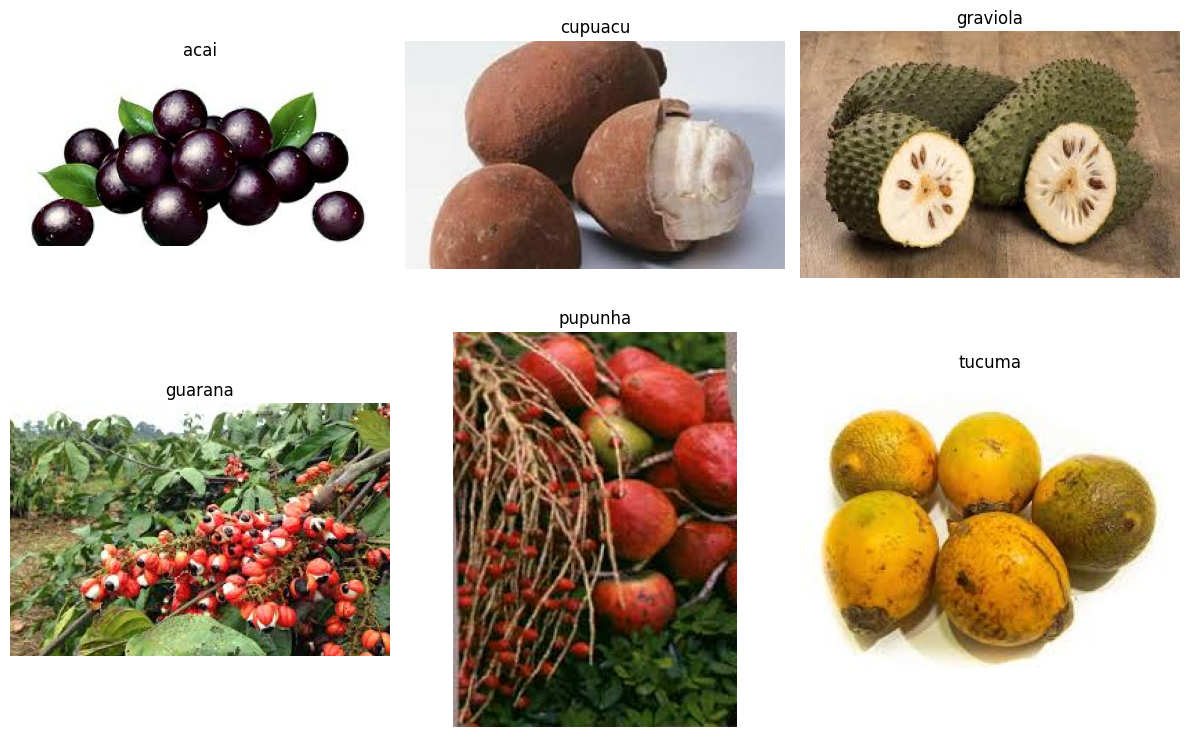

In [12]:
num_images = len(sample_images)
cols = math.ceil(num_images / 2)

plt.figure(figsize=(4 * cols, 8))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)
    plt.subplot(2, cols, i + 1)
    plt.imshow(img)
    plt.title(sample_labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

### Observation
The dataset contains multiple fruit classes stored in separate folders. Each class shows distinct visual features such as color, shape, and texture. Some variations in background and lighting are observed, which makes CNN suitable for feature extraction.

## Task 1 (Part 2): Corrupted Image Detection

In [13]:
corrupted_images = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, SyntaxError, OSError):
                corrupted_images.append(img_path)
                os.remove(img_path)
                print(f"Removed corrupted image: {img_path}")

if len(corrupted_images) == 0:
    print("No Corrupted Images Found")
else:
    print("Total corrupted images removed:", len(corrupted_images))

No Corrupted Images Found


## Task 2: Loading and Preprocessing Image Data

In [14]:
import tensorflow as tf
import numpy as np

In [15]:
train_dir = "/content/dataset/FruitinAmazon/train"
test_dir = "/content/dataset/FruitinAmazon/test"

img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2

In [16]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset="training",
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset="validation",
    seed=123
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


In [17]:
class_names = train_ds.class_names
print("Class names:", class_names)
print("Number of classes:", len(class_names))

Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [18]:
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

###Task3: Implement CNN Architecture


In [19]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(len(class_names), activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

7. Task 4: Model Compilation

In [20]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [22]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.0917 - loss: 1.9172
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_cnn_model.h5



Epoch 1: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 262ms/step - accuracy: 0.1250 - loss: 1.9002 - val_accuracy: 0.0000e+00 - val_loss: 1.9743
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.4319 - loss: 1.5726
Epoch 2: val_accuracy improved from 0.00000 to 0.16667, saving model to best_cnn_model.h5



Epoch 2: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 239ms/step - accuracy: 0.4306 - loss: 1.5238 - val_accuracy: 0.1667 - val_loss: 1.6953
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.4715 - loss: 1.2391
Epoch 3: val_accuracy improved from 0.16667 to 0.27778, saving model to best_cnn_model.h5



Epoch 3: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 227ms/step - accuracy: 0.5139 - loss: 1.1865 - val_accuracy: 0.2778 - val_loss: 1.6523
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.7326 - loss: 0.8462
Epoch 4: val_accuracy improved from 0.27778 to 0.72222, saving model to best_cnn_model.h5



Epoch 4: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 225ms/step - accuracy: 0.7361 - loss: 0.8174 - val_accuracy: 0.7222 - val_loss: 0.8585
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9299 - loss: 0.4577
Epoch 5: val_accuracy improved from 0.72222 to 0.83333, saving model to best_cnn_model.h5



Epoch 5: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step - accuracy: 0.9306 - loss: 0.4442 - val_accuracy: 0.8333 - val_loss: 0.7476
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9840 - loss: 0.2351
Epoch 6: val_accuracy improved from 0.83333 to 0.88889, saving model to best_cnn_model.h5



Epoch 6: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 224ms/step - accuracy: 0.9722 - loss: 0.2271 - val_accuracy: 0.8889 - val_loss: 0.4366
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9882 - loss: 0.0948
Epoch 7: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 279ms/step - accuracy: 0.9722 - loss: 0.1075 - val_accuracy: 0.8889 - val_loss: 0.4744
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 1.0000 - loss: 0.0526
Epoch 8: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 212ms/step - accuracy: 1.0000 - loss: 0.0489 - val_accuracy: 0.8333 - val_loss: 0.5725
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 1.0000 - loss: 0.0294
Epoch 9: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step - accuracy: 1.0000 - loss: 0.0280 - val_accuracy: 0.8333 - val_loss: 0.4750
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9837 - loss: 

###Accuracy and loss curves

In [23]:
test_loss, test_accuracy = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5667 - loss: 1.1873
Test Loss: 1.1873358488082886
Test Accuracy: 0.5666666626930237


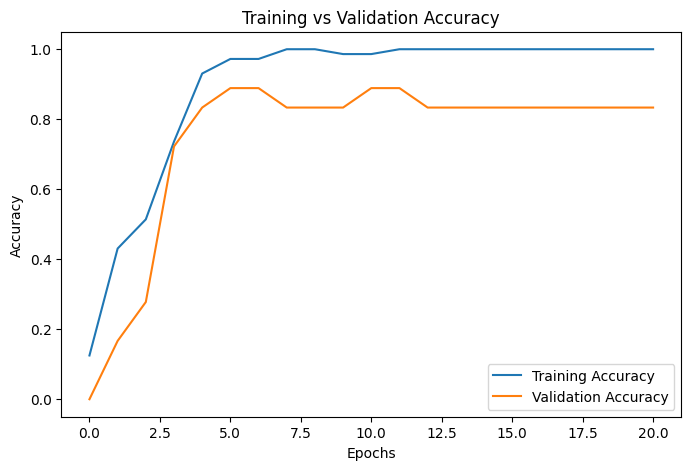

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

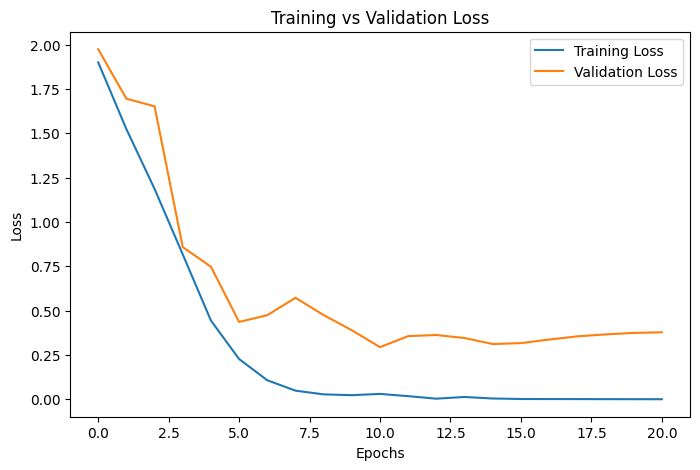

In [25]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

Task 8: Save and Load the Model

In [26]:
model.save("fruit_cnn_model.h5")
print("Model saved successfully")

Model saved successfully


In [27]:
loaded_model = tf.keras.models.load_model("fruit_cnn_model.h5")
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds)
print("Loaded Model Test Loss:", loaded_loss)
print("Loaded Model Test Accuracy:", loaded_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5667 - loss: 1.1873 
Loaded Model Test Loss: 1.1873358488082886
Loaded Model Test Accuracy: 0.5666666626930237


Task 9: Predictions and Classification Report

In [28]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        acai       0.75      0.60      0.67         5
     cupuacu       0.67      0.40      0.50         5
    graviola       0.45      1.00      0.62         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.56      1.00      0.71         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.57        30
   macro avg       0.52      0.57      0.50        30
weighted avg       0.52      0.57      0.50        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
